In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def dump_indexes_to_txt(
    df: pd.DataFrame,
    output_path: Path,
) -> None:
    """
    Dump the indexes from a feather file to a text file.
    """
    values = df.index.to_list()
    # create a text file, one line per k-mer
    with output_path.open("w") as f:
        for value in values:
            f.write(f"{value}\n")

    print(f"Dumped {len(values)} to {output_path}")

In [3]:
def read_bed_file(
    bed_path: Path | str,
) -> pd.DataFrame:
    """
    Read a BED file and return a DataFrame.
    """
    df = pd.read_csv(bed_path, sep="\t", header=None, names=["chrom", "start", "end", "kmer"])
    df["chrom"] = df["chrom"].astype("category")
    return df

In [4]:
def plot_kmer_distribution(
    bed_path: Path | str,
):
    """
    Plot the distribution of k-mer positions for each chromosome.
    """

    df = read_bed_file(bed_path)

    print(f"Loaded {len(df)} k-mer mappings of {df['kmer'].nunique()} unique K-mers")

    grouping = df.groupby("chrom")

    fig, axes = plt.subplots(nrows=len(grouping), figsize=(12, 5 * len(grouping)))

    for i, (chrom, group) in enumerate(grouping):
        sns.histplot(group["start"], bins=100, ax=axes[i], kde=True)
        axes[i].set_title(f"K-mer Positions in {chrom}")
        axes[i].set_xlabel("Position")
        axes[i].set_ylabel("Frequency")


In [5]:
def plot_kmer_distributions(
    bed_paths: dict[str, Path | str],
):
    """
    Plot the distribution of k-mer positions for each chromosome for each mapping in a grid.
    """

    dfs = {name: read_bed_file(bed_path) for name, bed_path in bed_paths.items()}

    for name, df in dfs.items():
        print(
            f"Loaded {len(df)} k-mer mappings of {df['kmer'].nunique()} unique K-mers from {name}"
        )

    groupings = {name: df.groupby("chrom") for name, df in dfs.items()}

    group_count = max(len(grouping) for grouping in groupings.values())

    fig, axes = plt.subplots(
        nrows=len(dfs),
        ncols=group_count,
        figsize=(4 * group_count, 4 * len(dfs)),
        sharex="col",
        sharey="col",
    )

    for i, (name, grouping) in enumerate(groupings.items()):
        for j, (chrom, group) in enumerate(grouping):
            ax = axes[i, j]
            sns.histplot(group["start"], bins=100, ax=ax, kde=True)
            ax.set_title(f"{name} - {chrom}")
            ax.set_xlabel("Position")
            ax.set_ylabel("Frequency")

In [8]:
dump_indexes_to_txt(
    df=pd.read_feather("../data/joined-counts.df3.zstd8.feather"),
    output_path=Path("../data/kmers.df3.txt"),
)

Dumped 216196 to ../data/kmers.df3.txt


In [9]:
dump_indexes_to_txt(
    df=pd.read_feather("../data/joined-counts.df4.zstd8.feather"),
    output_path=Path("../data/kmers.df4.txt"),
)

Dumped 37183 to ../data/kmers.df4.txt


In [12]:
rmap_path = Path("../../rmap/target/release/rmap")
rmap_path.exists()

True

In [14]:
!{rmap_path} ../data/kmers.df3.txt ../data/assemblies/ColCEN.fasta -o ../data/kmers.df3.ColCEN.bed
!{rmap_path} ../data/kmers.df3.txt ../data/assemblies/ColPEK.fasta -o ../data/kmers.df3.ColPEK.bed
!{rmap_path} ../data/kmers.df3.txt ../data/assemblies/ColXJTU.fasta -o ../data/kmers.df3.ColXJTU.bed

Reading k-mer list ../data/kmers.df3.txt...
Reading FASTA file ../data/assemblies/ColCEN.fasta...
⠁ [00:00:00] [#####>----------------------------------]       1/7       Indexing...
⠉ [00:00:00] [###########>----------------------------]       2/7       Indexing...
⠉ [00:00:00] [###########>----------------------------]       2/7       Indexing...
⠙ [00:00:10] [#################>----------------------]       3/7       Indexing...
⠚ [00:00:11] [######################>-----------------]       4/7       Indexing...
⠚ [00:00:11] [######################>-----------------]       4/7       Indexing...
⠚ [00:00:11] [######################>-----------------]       4/7       Indexing...
⠒ [00:00:14] [############################>-----------]       5/7       Indexing...
⠒ [00:00:14] [############################>-----------]       5/7       Indexing...
⠂ [00:00:16] [##################################>-----]       6/7       Indexing...
⠂ [00:00:16] [##################################>-----]       

Loaded 10537 k-mer mappings of 6601 unique K-mers from ColCEN
Loaded 9577 k-mer mappings of 6458 unique K-mers from ColPEK
Loaded 9427 k-mer mappings of 6319 unique K-mers from ColXJTU


/tmp/ipykernel_13559/2916073306.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groupings = {name: df.groupby("chrom") for name, df in dfs.items()}


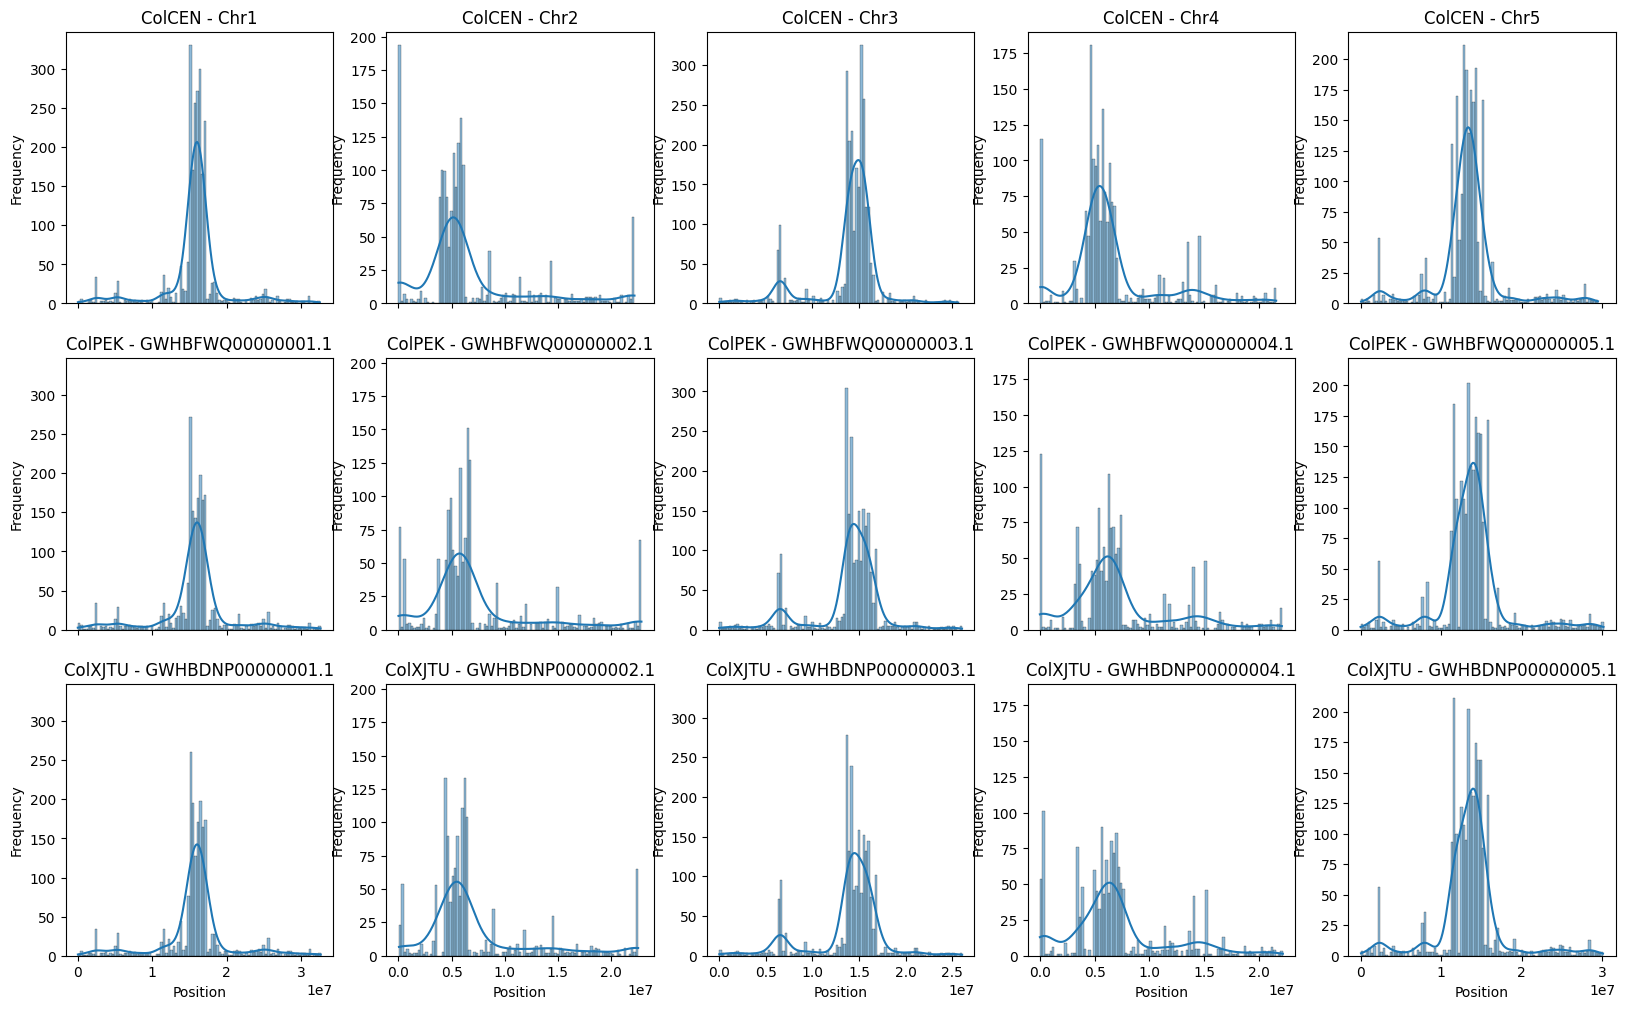

In [15]:
plot_kmer_distributions(bed_paths={
    assembly: f"../data/kmers.df3.{assembly}.bed"
    for assembly in ["ColCEN", "ColPEK", "ColXJTU"]
})

In [16]:
!{rmap_path} ../data/kmers.df4.txt ../data/assemblies/ColCEN.fasta -o ../data/kmers.df4.ColCEN.bed
!{rmap_path} ../data/kmers.df4.txt ../data/assemblies/ColPEK.fasta -o ../data/kmers.df4.ColPEK.bed
!{rmap_path} ../data/kmers.df4.txt ../data/assemblies/ColXJTU.fasta -o ../data/kmers.df4.ColXJTU.bed

Reading k-mer list ../data/kmers.df4.txt...
Reading FASTA file ../data/assemblies/ColCEN.fasta...
⠁ [00:00:00] [#####>----------------------------------]       1/7       Indexing...
⠉ [00:00:00] [###########>----------------------------]       2/7       Indexing...
⠉ [00:00:00] [###########>----------------------------]       2/7       Indexing...
⠙ [00:00:10] [#################>----------------------]       3/7       Indexing...
⠙ [00:00:10] [#################>----------------------]       3/7       Indexing...
⠚ [00:00:11] [######################>-----------------]       4/7       Indexing...
⠚ [00:00:11] [######################>-----------------]       4/7       Indexing...
⠒ [00:00:14] [############################>-----------]       5/7       Indexing...
⠒ [00:00:14] [############################>-----------]       5/7       Indexing...
⠂ [00:00:16] [##################################>-----]       6/7       Indexing...
⠂ [00:00:16] [##################################>-----]       

Loaded 1374 k-mer mappings of 1024 unique K-mers from ColCEN
Loaded 1215 k-mer mappings of 976 unique K-mers from ColPEK
Loaded 1160 k-mer mappings of 928 unique K-mers from ColXJTU


/tmp/ipykernel_13559/2916073306.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groupings = {name: df.groupby("chrom") for name, df in dfs.items()}


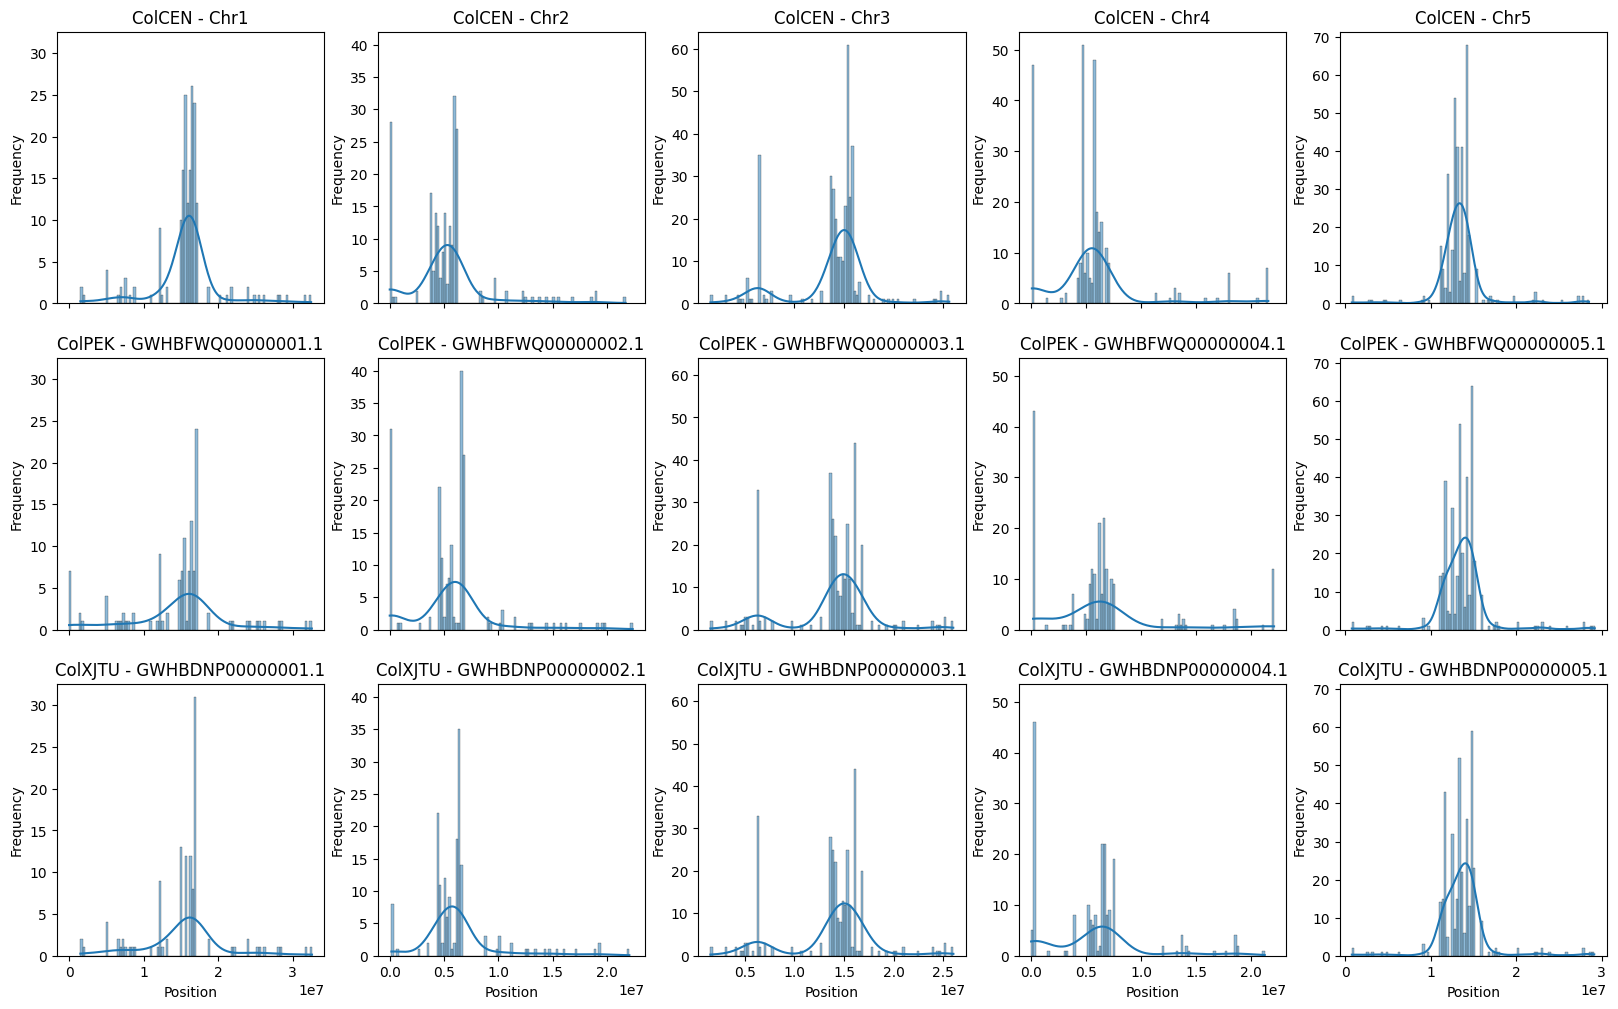

In [17]:
plot_kmer_distributions(bed_paths={
    assembly: f"../data/kmers.df4.{assembly}.bed"
    for assembly in ["ColCEN", "ColPEK", "ColXJTU"]
})